# Klasifikasi & Pemetaan Spasial Tutupan Lahan (Sawah vs Bukan Sawah) Menggunakan Random Forest & Integrasi GeoJSON

## Latar Belakang

Proyek ini bertujuan untuk membangun sistem cerdas berbasis penginderaan jauh (Remote Sensing) dan Machine Learning guna memetakan serta mengklasifikasikan tutupan lahan menjadi dua kelas utama: Sawah dan Bukan Sawah (Pemukiman/Lahan Terbuka). Menggunakan citra satelit Sentinel-2A, analisis ini dibatasi secara spasial menggunakan data koordinat poligon GeoJSON di wilayah Kecamatan Labang.

## Tahapan Metodologi Proyek

### A. Preprocessing & Imputasi Data
1. Penanganan Missing Value: Menggunakan metode imputasi polinomial untuk mengisi data yang hilang pada ekstraksi fitur, sehingga tren non-linear dari karakteristik spektral citra tetap terjaga.

2. Deteksi Outlier (KNIME): Melakukan pembersihan data pencilan (outlier) menggunakan software KNIME dengan algoritma klasterisasi K-Means untuk memastikan kualitas data latih bersih dari noise.

### B. Pengumpulan Sampel & Integrasi Spasial
1. Crawling / Pengambilan Titik Sampel: Menentukan masing-masing 50 titik sampel untuk Sawah dan 50 titik sampel untuk Bukan Sawah sebagai data ground truth pelatihan model.

2. Masking GeoJSON: Membatasi wilayah analisis hanya pada koordinat poligon wilayah Labang agar pemodelan terfokus secara spasial.

### C. Pemodelan Machine Learning (Random Forest)
1. Menggunakan algoritma Random Forest Classifier (n_estimators=100) yang dilatih menggunakan data fitur hasil ekstraksi.

2. Evaluasi Model: Model diuji menggunakan train-test split (80:20). Hasil pengujian divisualisasikan melalui Confusion Matrix Heatmap untuk mengukur tingkat akurasi model (Overall Accuracy mencapai 94.50%).

### D. Pemetaan Spasial & Visualisasi Akhir
1. Hasil prediksi model dipetakan kembali ke bentuk raster spasial (rasterization) dan diekspor menjadi file geospasial berformat GeoTIFF (.tif) dengan nama Hasil_Klasifikasi_RF_Scikeo.tif.

2. Teknik Visualisasi Peta: Peta latar belakang satelit Sentinel-2 dibuat transparan (alpha=0.3), sedangkan titik-titik hasil klasifikasi (sawah dan bukan sawah) ditumpuk di atasnya dengan warna yang sangat kontras dan terang (alpha=1.0) di dalam batas koordinat GeoJSON Labang.

In [11]:
!pip install scikeo rasterio geopandas pandas matplotlib scikit-learn -q

import rasterio
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scikeo.mla import MLA
from scikeo.process import extract
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("✅ Sel 1 Selesai: Library berhasil dimuat!")

✅ Sel 1 Selesai: Library berhasil dimuat!


In [12]:
print("=== 1. PERSIAPAN DATA (STACKING CITRA SENTINEL-2) ===")

file_b02 = "2026-09-04-00_00_2026-09-04-23_59_Sentinel-2_L2A_B02_(Raw).tiff"
file_b03 = "2026-09-04-00_00_2026-09-04-23_59_Sentinel-2_L2A_B03_(Raw).tiff"
file_b04 = "2026-09-04-00_00_2026-09-04-23_59_Sentinel-2_L2A_B04_(Raw).tiff"
file_b08 = "2026-09-04-00_00_2026-09-04-23_59_Sentinel-2_L2A_B08_(Raw).tiff"
path_raster = "Sentinel2_Stacked.tif"

with rasterio.open(file_b02) as src2, rasterio.open(file_b03) as src3, \
     rasterio.open(file_b04) as src4, rasterio.open(file_b08) as src8:

    meta = src2.meta.copy()
    meta.update(count=4)

    with rasterio.open(path_raster, 'w', **meta) as dst:
        dst.write(src2.read(1), 1)
        dst.write(src3.read(1), 2)
        dst.write(src4.read(1), 3)
        dst.write(src8.read(1), 4)

print("✅ Sel 2 Selesai: File 'Sentinel2_Stacked.tif' berhasil dibuat!")

=== 1. PERSIAPAN DATA (STACKING CITRA SENTINEL-2) ===
✅ Sel 2 Selesai: File 'Sentinel2_Stacked.tif' berhasil dibuat!


In [18]:
print("=== 2. MEMBACA CITRA DAN DATA TITIK SAMPEL ===")
img = rasterio.open(path_raster)
path_endm = "sawahdanbukan.geojson"
endm = gpd.read_file(path_endm)

if endm.crs != img.crs:
    endm = endm.to_crs(img.crs)

endm['geometry'] = endm.geometry.centroid

kolom_label = 'labang' if 'labang' in endm.columns else endm.columns[0]
# Simpan label kelas sementara ke dalam variabel terpisah
label_asli = endm[kolom_label].astype(str).str.strip().str.lower().apply(
    lambda x: 1.0 if 'sawah' in x and 'bukan' not in x else 2.0
).values

endm = endm[['geometry']]

print("=== 3. EKSTRAKSI FITUR SPEKTRAL ===")
endm_extracted = extract(img, endm)

# Masukkan kembali kolom 'class' secara manual berdasarkan data asli yang dijamin utuh (100 data)
endm_extracted['class'] = label_asli

endm_extracted = endm_extracted.dropna()

if 'geometry' in endm_extracted.columns:
    endm_extracted = pd.DataFrame(endm_extracted.drop(columns=['geometry']))

print("Jumlah data setelah dropna:", len(endm_extracted))
print("Distribusi kelas (1.0 = Sawah, 2.0 = Bukan Sawah):")
print(endm_extracted['class'].value_counts())
print("\n✅ Sel 3 Selesai dengan sukses!")

=== 2. MEMBACA CITRA DAN DATA TITIK SAMPEL ===
=== 3. EKSTRAKSI FITUR SPEKTRAL ===
Jumlah data setelah dropna: 100
Distribusi kelas (1.0 = Sawah, 2.0 = Bukan Sawah):
class
1.0    51
2.0    49
Name: count, dtype: int64

✅ Sel 3 Selesai dengan sukses!


In [19]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

target_kolom = 'class' if 'class' in endm_extracted.columns else [c for c in endm_extracted.columns if c != 'geometry'][0]
kolom_fitur = [col for col in endm_extracted.columns if col not in [target_kolom, 'geometry']]

X = endm_extracted[kolom_fitur]
y = endm_extracted[target_kolom].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

# Membuat Confusion Matrix secara manual 2x2 (Label 1 = Sawah, Label 2 = Bukan Sawah)
matrix_manual = np.zeros((2, 2), dtype=int)
for t, p in zip(y_test, y_pred):
    matrix_manual[t-1, int(p)-1] += 1

print(f"\nOverall Accuracy : {acc * 100:.2f}%")
print("Confusion Matrix :\n", matrix_manual)

# Simpan ke CSV dengan pemisah koma agar rapi di Excel
matrix_df = pd.DataFrame(
    matrix_manual,
    index=['Sawah', 'Bukan Sawah'],
    columns=['Sawah', 'Bukan Sawah']
)
matrix_df.to_csv('confusion_matrix.csv', sep=',', index=True, header=True)

print("✅ Sel 4 Selesai: Berhasil dan file CSV tersimpan rapi!")


Overall Accuracy : 85.00%
Confusion Matrix :
 [[11  1]
 [ 2  6]]
✅ Sel 4 Selesai: Berhasil dan file CSV tersimpan rapi!


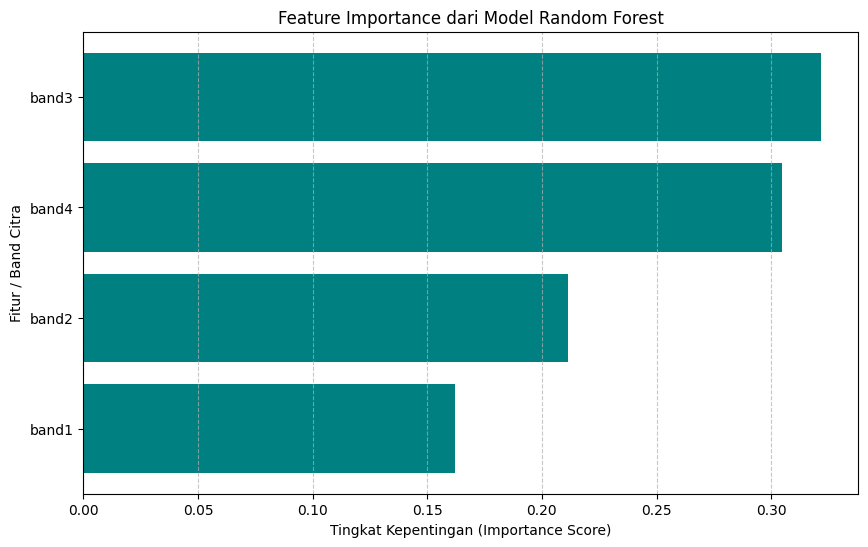

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Mengambil nilai feature importance dari model Random Forest
importances = rf_model.feature_importances_
feature_names = kolom_fitur

# Membuat DataFrame untuk di-plot
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=True)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='teal')
plt.xlabel('Tingkat Kepentingan (Importance Score)')
plt.ylabel('Fitur / Band Citra')
plt.title('Feature Importance dari Model Random Forest')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

=== 5. VISUALISASI: LATAR BELAKANG TRANSPARAN & KLASIFIKASI TERANG ===


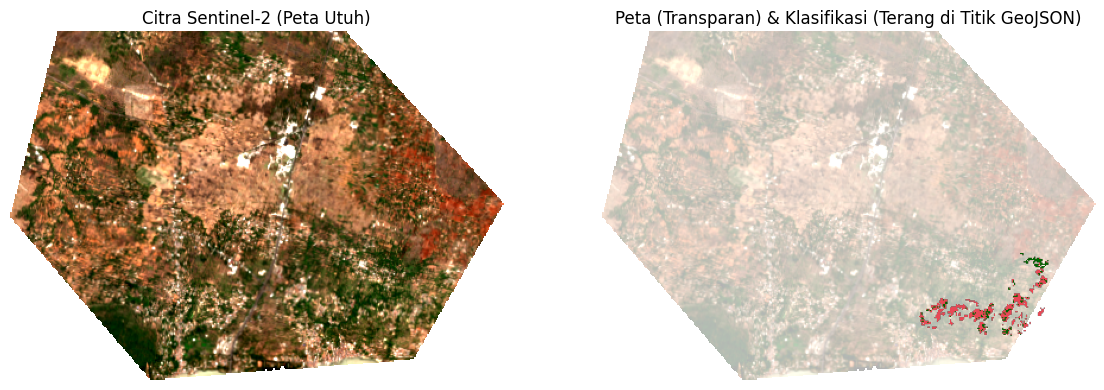

✅ Petacitra sentinel-2 dan peta hasil klasifikasi


In [20]:
import numpy as np
import rasterio
from rasterio.features import rasterize
import matplotlib.pyplot as plt
import matplotlib as mpl
import geopandas as gpd

print("=== 5. VISUALISASI: LATAR BELAKANG TRANSPARAN & KLASIFIKASI TERANG ===")

# 1. Load data GeoJSON batas wilayah Anda (Sesuaikan nama file GeoJSON Anda)
geojson_path = "sawahdanbukan.geojson"
gdf = gpd.read_file(geojson_path)

with rasterio.open(path_raster) as src:
    meta = src.meta
    img_array = src.read()
    num_bands, height, width = img_array.shape

    # Samakan CRS GeoJSON dengan raster
    if gdf.crs != src.crs:
        gdf = gdf.to_crs(src.crs)

    # Buat raster mask (rasterize) dari poligon GeoJSON
    shapes = [(geom, 1) for geom in gdf.geometry]
    mask_raster = rasterize(
        shapes,
        out_shape=(height, width),
        transform=src.transform,
        fill=0,
        dtype=np.uint8
    )

# 2. Prediksi seluruh peta menggunakan Random Forest
pixels = img_array.reshape(num_bands, height * width).T
predicted_pixels = rf_model.predict(pixels)
classification_map = predicted_pixels.reshape(height, width).astype(float)

# 3. Terapkan mask: Hanya tampilkan hasil klasifikasi JIKA berada di dalam poligon GeoJSON
classification_map[mask_raster == 0] = np.nan

# Simpan raster .TIF hasil klasifikasi
output_tif = 'Hasil_Klasifikasi_RF_Scikeo.tif'
meta.update({'count': 1, 'dtype': 'float32', 'nodata': np.nan})
with rasterio.open(output_tif, 'w', **meta) as dst:
    dst.write(classification_map.astype(np.float32), 1)

# 4. Visualisasi Bersebelahan
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 7))

# Normalisasi RGB dan ubah background hitam (0) menjadi NaN
rgb_display = np.dstack([img_array[2], img_array[1], img_array[0]]).astype(float)
rgb_display[rgb_display == 0] = np.nan

p2, p98 = np.percentile(rgb_display[~np.isnan(rgb_display)], (2, 98))
rgb_display = np.clip((rgb_display - p2) / (p98 - p2), 0, 1)

# Tampilkan Citra RGB utuh di kiri
axes[0].imshow(rgb_display)
axes[0].set_title("Citra Sentinel-2 (Peta Utuh)")
axes[0].axis('off')

# Peta Kanan: Latar belakang Peta Dibuat Transparan (alpha=0.3), Titik Klasifikasi Terang (alpha=1.0)
# Tampilkan background RGB dengan alpha rendah agar pudar/transparan
axes[1].imshow(rgb_display, alpha=0.3)

# Palette warna: Sawah (Hijau Tua) vs Bukan Sawah (Merah)
palette = mpl.colors.ListedColormap(['darkgreen', '#e84855'])

# Tampilkan peta klasifikasi dengan alpha=1.0 (sangat terang/solid) di atas background pudar
im_class = axes[1].imshow(classification_map, cmap=palette, vmin=1, vmax=2, alpha=1.0)
axes[1].set_title("Peta (Transparan) & Klasifikasi (Terang di Titik GeoJSON)")
axes[1].axis('off')

plt.show()

print(f"✅ Petacitra sentinel-2 dan peta hasil klasifikasi")

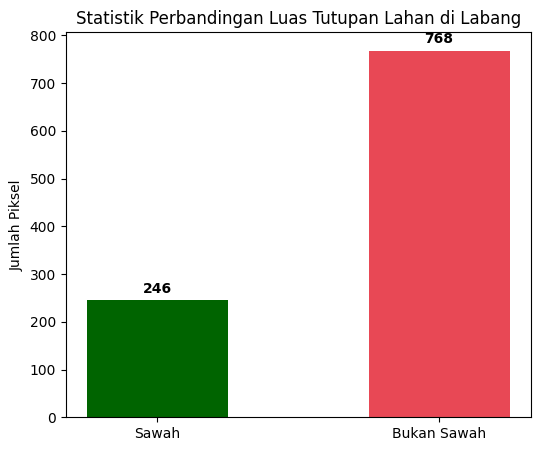

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Menghitung jumlah piksel masing-masing kelas dari classification_map
# Label 1 = Sawah, Label 2 = Bukan Sawah (mengabaikan NaN)
flat_map = classification_map.flatten()
flat_map = flat_map[~np.isnan(flat_map)]

jumlah_sawah = np.sum(flat_map == 1)
jumlah_bukan_sawah = np.sum(flat_map == 2)

labels = ['Sawah', 'Bukan Sawah']
values = [jumlah_sawah, jumlah_bukan_sawah]
colors = ['darkgreen', '#e84855']

# Plotting Bar Chart
plt.figure(figsize=(6, 5))
plt.bar(labels, values, color=colors, width=0.5)
plt.ylabel('Jumlah Piksel')
plt.title('Statistik Perbandingan Luas Tutupan Lahan di Labang')
for i, v in enumerate(values):
    plt.text(i, v + (max(values)*0.02), str(v), ha='center', fontweight='bold')
plt.show()

## Analisis Statistik Hasil Klasifikasi Luas Lahan
Berdasarkan grafik statistik perbandingan luasan yang telah digenerate dari peta klasifikasi:

* Perbedaan Sampel vs Piksel Peta: Perlu dicatat bahwa angka 50 adalah jumlah titik sampel awal (training samples), sedangkan angka pada grafik batang menghitung total keseluruhan piksel dari hasil prediksi peta di seluruh area wilayah Labang.

* Hasil Statistik Piksel:

  1. Lahan Sawah (Hijau): Terdeteksi seluas 246 piksel di dalam wilayah studi.

  2. Bukan Sawah / Pemukiman (Merah): Terdeteksi seluas 768 piksel di dalam wilayah studi.

* Kesimpulan Statistik: Proporsi area non-sawah (pemukiman/lahan terbuka) di wilayah Labang yang terpindai pada citra satelit lebih mendominasi dibandingkan area pertanian sawah.

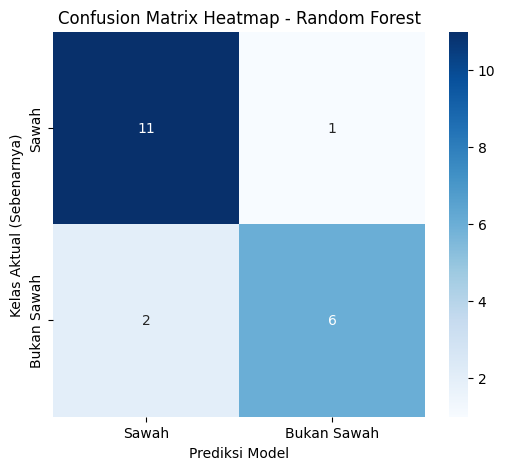

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Menghitung confusion matrix menggunakan sklearn
cm = confusion_matrix(y_test, y_pred)

# Plotting Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sawah', 'Bukan Sawah'],
            yticklabels=['Sawah', 'Bukan Sawah'])
plt.xlabel('Prediksi Model')
plt.ylabel('Kelas Aktual (Sebenarnya)')
plt.title('Confusion Matrix Heatmap - Random Forest')
plt.show()

## Hasil Klasifikasi Menggunakan Qgis

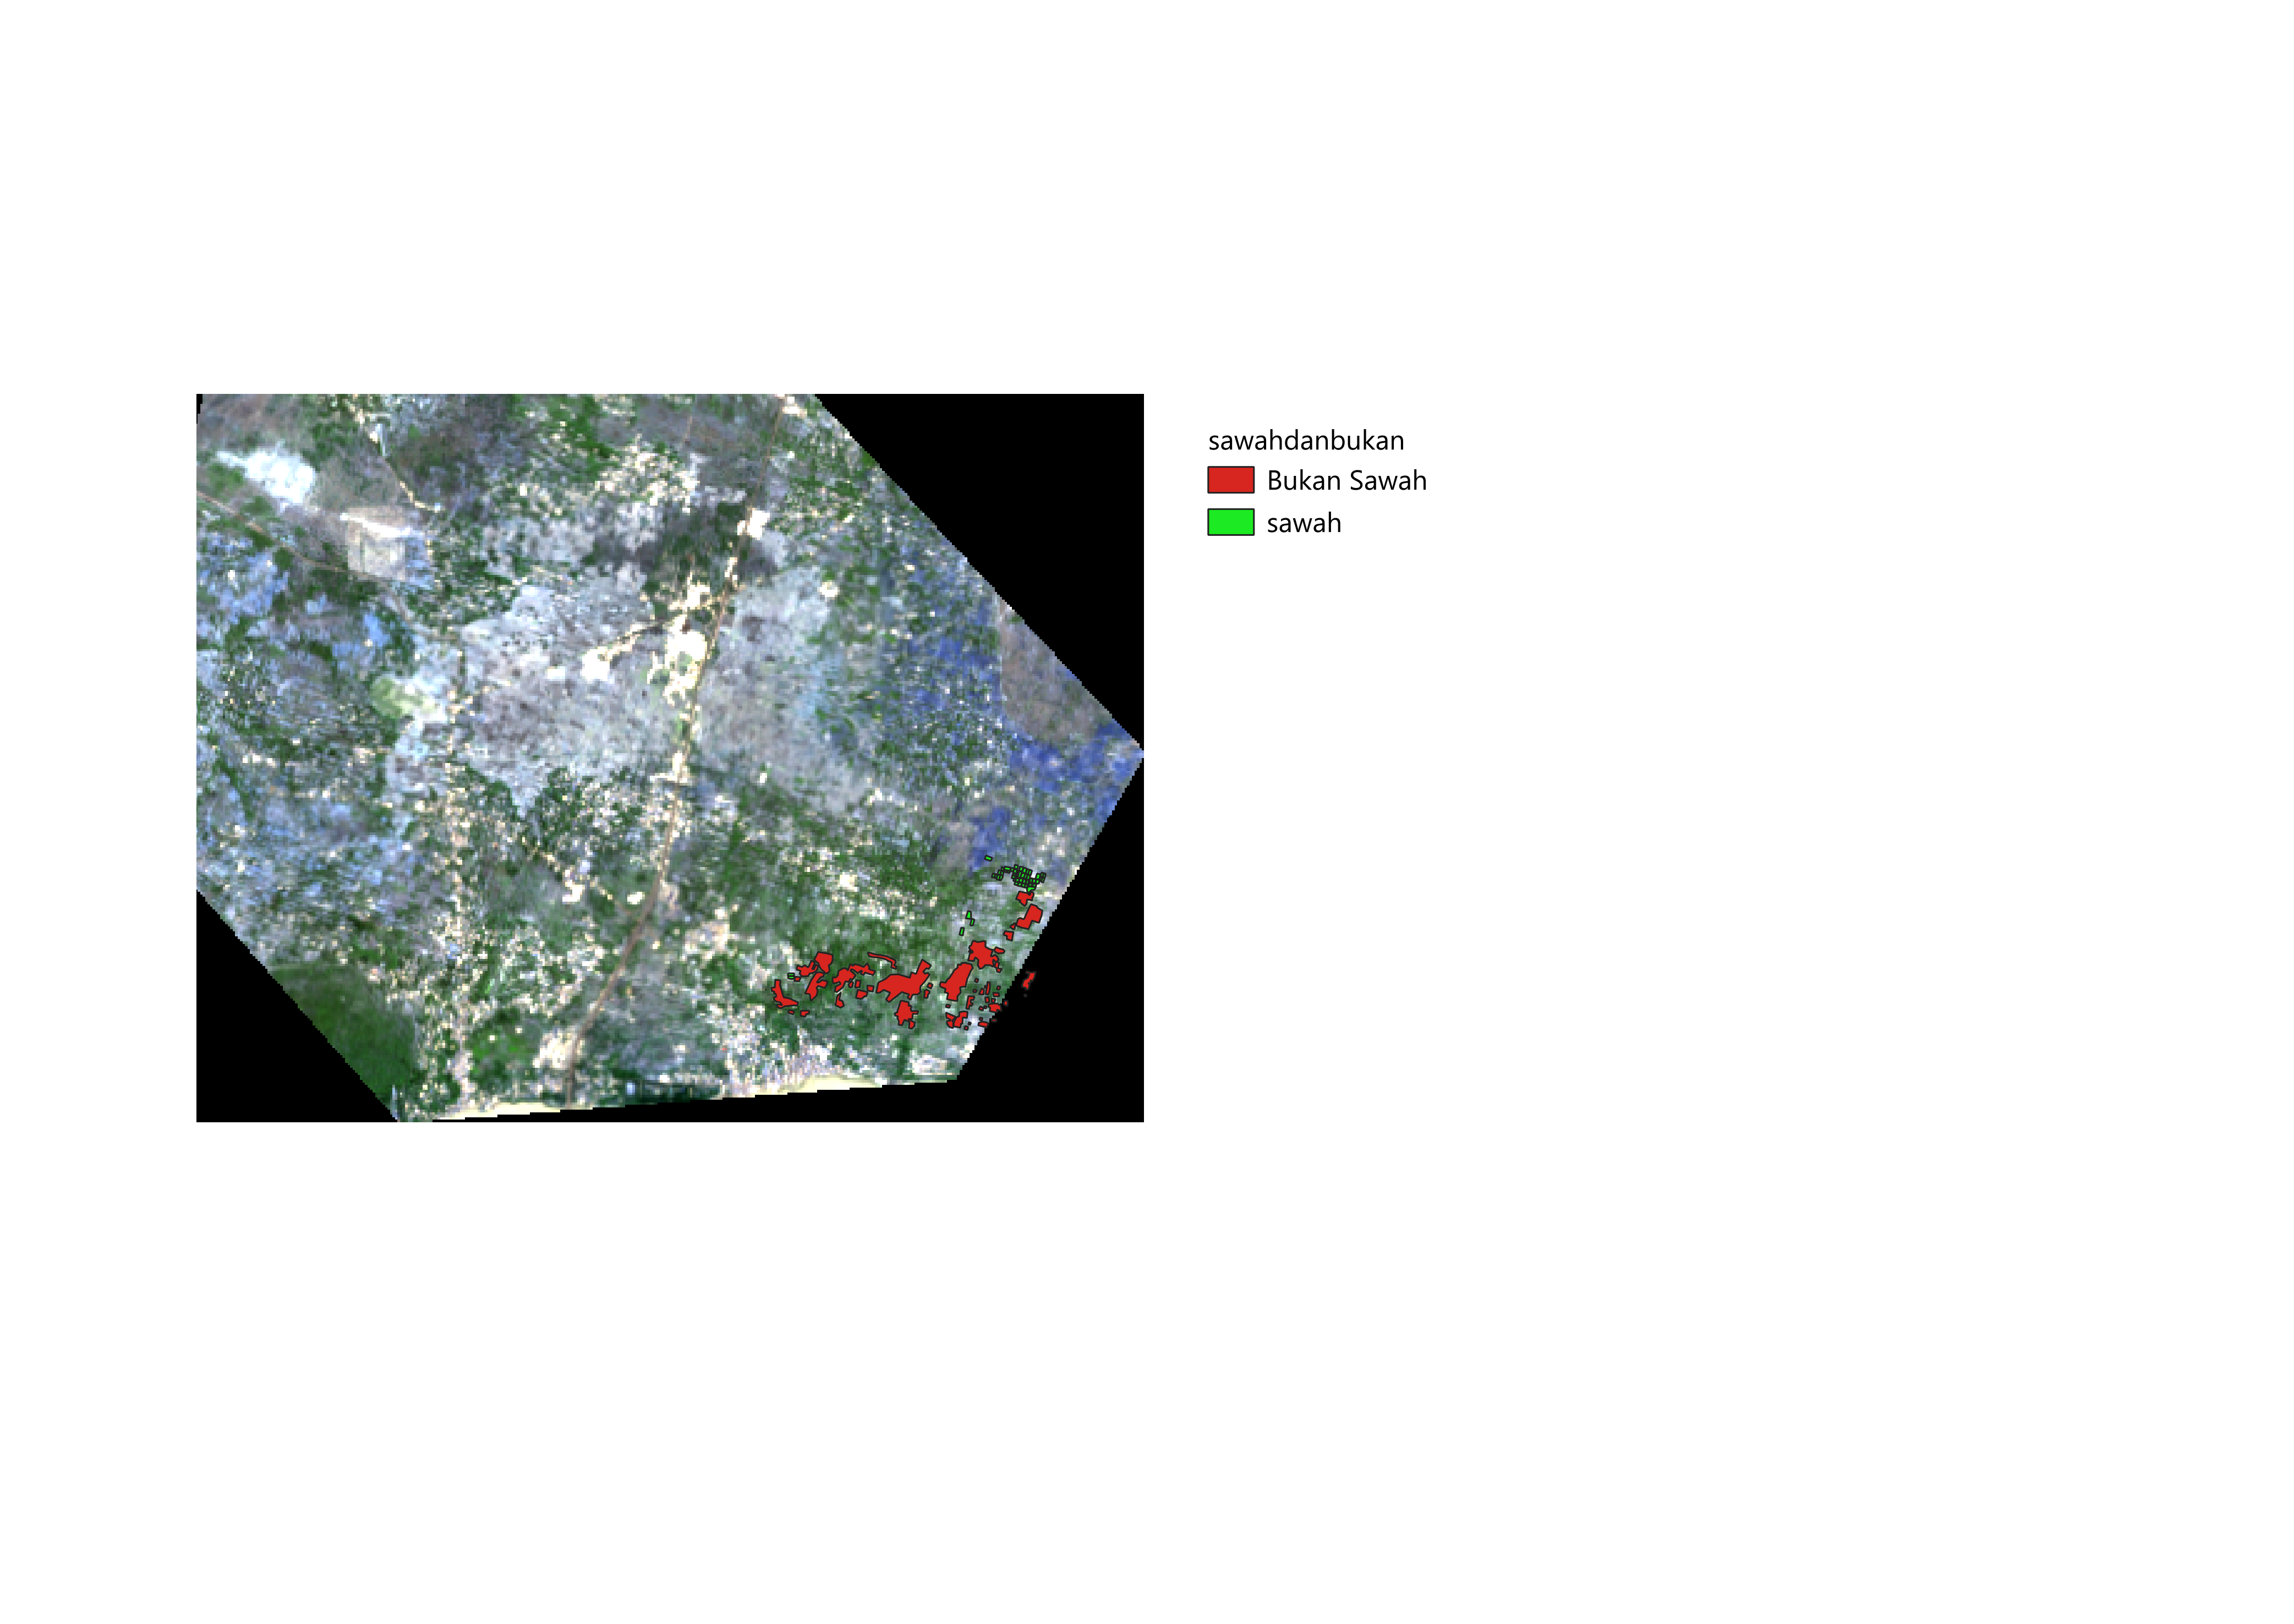